Objective : The objective of this experiment is to understand the classification using decision tree algorithm. The aim is to develop and understand how decision tree classifier can be used to categorise data into multiple classes. The experiment focuses on understanding how tree structure is formed. How splitting of data occurs using criteria eini index and how model training model prediction. Also aim to understand how to visualise decision tree interpret it's structure and evaluate the model using confusion matrix and accruracy score.

flower: Setosa,Versicolor, Verginica

In [ ]:
import numpy as np

In [ ]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Step 1: Load the dataset
irisset = datasets.load_iris()

X = irisset.data
Y = irisset.target

In [ ]:
print(irisset.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# Step 3: Split dataset into training and testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
)

In [ ]:
# Step 4: Create Decision Tree model
cf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=5
)

In [ ]:
# Step 5: Train the model
cf.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=5)

In [ ]:
# Step 6: Make predictions
Y_pred = cf.predict(X_test)

In [ ]:
# Step 7: Evaluate the model
# Accuracy score
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


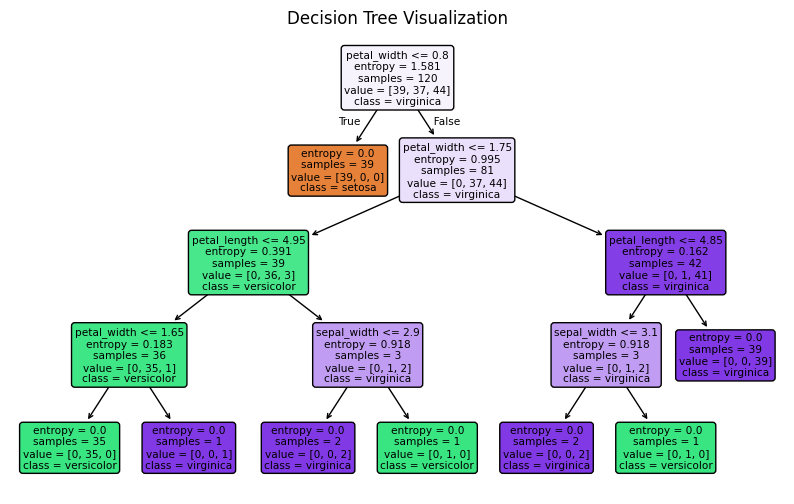

In [ ]:
 #Step 8: Visualize Decision Tree

plt.figure(figsize=(10,6))

plot_tree(
    cf,
    feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"],
    class_names=["setosa", "versicolor", "virginica"],
    filled=True,
    rounded=True
    )
plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
text_representation = tree.export_text(
    cf,
    feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

print(text_representation)

|--- petal_width <= 0.80
|   |--- class: 0
|--- petal_width >  0.80
|   |--- petal_width <= 1.75
|   |   |--- petal_length <= 4.95
|   |   |   |--- petal_width <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal_width >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal_length >  4.95
|   |   |   |--- sepal_width <= 2.90
|   |   |   |   |--- class: 2
|   |   |   |--- sepal_width >  2.90
|   |   |   |   |--- class: 1
|   |--- petal_width >  1.75
|   |   |--- petal_length <= 4.85
|   |   |   |--- sepal_width <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- sepal_width >  3.10
|   |   |   |   |--- class: 1
|   |   |--- petal_length >  4.85
|   |   |   |--- class: 2



**For geopolitical_datasets**

In [ ]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("geopolitical_dataset.csv")

In [ ]:
print(df.head())

   military_power_ratio  troop_movement  nuclear_capability  nuclear_warheads  \
0              1.061810              46                   0                20   
1              1.926071              11                   0               157   
2              1.597991              61                   0               268   
3              1.397988              79                   0               161   
4              0.734028              87                   1               259   

   gdp_ratio  sanctions_intensity  trade_dependency  ideology_distance  \
0   1.514162                    7          0.949273           0.844864   
1   1.915973                    7          0.879601           0.359676   
2   0.903452                    9          0.907042           0.687234   
3   1.213110                    6          0.991533           0.312834   
4   1.451510                    4          0.208315           0.060906   

   political_stability  historical_conflict  border_distance  news_s

In [ ]:
target_column = "target"
X = df.drop(target_column, axis=1)   # Features
Y = df[target_column]

In [ ]:
print(X.columns)

Index(['military_power_ratio', 'troop_movement', 'nuclear_capability',
       'nuclear_warheads', 'gdp_ratio', 'sanctions_intensity',
       'trade_dependency', 'ideology_distance', 'political_stability',
       'historical_conflict', 'border_distance', 'news_sentiment',
       'nationalism_index', 'leader_aggression'],
      dtype='object')


In [ ]:
# Handle non-numeric data (If present)
X = pd.get_dummies(X)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
)

In [ ]:
cf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,         # You can adjust this
    random_state=5
)
cf.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=3, random_state=5)

In [ ]:
Y_pred = cf.predict(X_test)

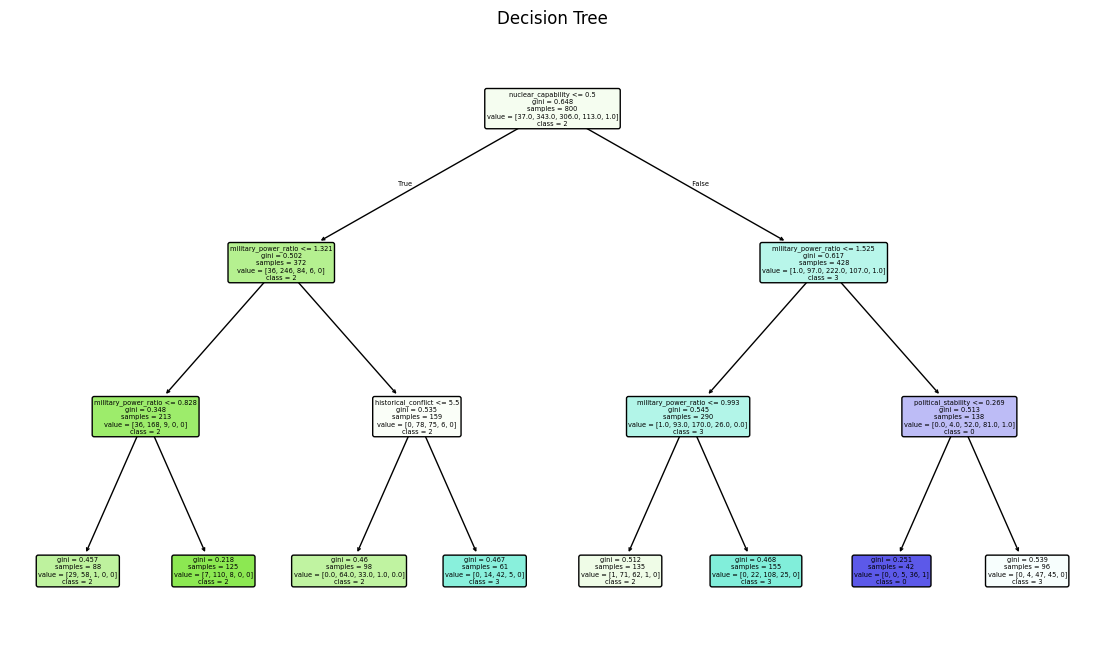

In [ ]:
# Create decision tree
plt.figure(figsize=(14, 8))
plot_tree(
    cf,
    feature_names=X.columns,
    class_names=[str(i) for i in Y.unique()],
    filled=True,
    rounded=True
)
plt.title("Decision Tree")
plt.show()

In [ ]:
# Text reresentation of decision tree
text_representation = tree.export_text(
    cf,
    feature_names=list(X.columns)
)

print("\nDecision Tree Rules:\n")
print(text_representation)


Decision Tree Rules:

|--- nuclear_capability <= 0.50
|   |--- military_power_ratio <= 1.32
|   |   |--- military_power_ratio <= 0.83
|   |   |   |--- class: 1
|   |   |--- military_power_ratio >  0.83
|   |   |   |--- class: 1
|   |--- military_power_ratio >  1.32
|   |   |--- historical_conflict <= 5.50
|   |   |   |--- class: 1
|   |   |--- historical_conflict >  5.50
|   |   |   |--- class: 2
|--- nuclear_capability >  0.50
|   |--- military_power_ratio <= 1.52
|   |   |--- military_power_ratio <= 0.99
|   |   |   |--- class: 1
|   |   |--- military_power_ratio >  0.99
|   |   |   |--- class: 2
|   |--- military_power_ratio >  1.52
|   |   |--- political_stability <= 0.27
|   |   |   |--- class: 3
|   |   |--- political_stability >  0.27
|   |   |   |--- class: 2



**Train Random Forest**

In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,   # number of trees
    criterion='gini',
    max_depth=4,
    random_state=42)

rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=4, random_state=42)

In [ ]:
# Make predictions
Y_pred_rf = rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred_rf)

print("Accuracy:", accuracy)

Accuracy: 0.77


**XG Boost**

In [ ]:
from xgboost import XGBClassifier

# Create model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train
model.fit(X_train, Y_train)

# Predict
Y_pred_xgb = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(Y_test, Y_pred_xgb)

print("Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:06:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.81
